In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns)

# 2. Clean missing values (represented as '?' in this dataset)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Convert columns that were string because of '?' to float
df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

# 3. Binarize the target (0 = no disease, 1-4 = disease present)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# 4. Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# 5. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scale numerical features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names (important for LIME/Anchors)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")
print("Data preprocessing complete!")

Training data shape: (237, 13)
Testing data shape: (60, 13)
Data preprocessing complete!


In [30]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Initialize the models
# Using a fixed random state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Train the models on the scaled data
print("Training models...")
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
rf_preds = rf_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test_scaled)

# 4. Evaluate performance
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("\n Model Evaluation ")
print(f"Random Forest -> Accuracy: {rf_acc:.4f} | F1-Score: {rf_f1:.4f}")
print(f"XGBoost       -> Accuracy: {xgb_acc:.4f} | F1-Score: {xgb_f1:.4f}")

# Let's use the Random Forest for the upcoming explanation step.
black_box_model = xgb_model

Training models...

 Model Evaluation 
Random Forest -> Accuracy: 0.8667 | F1-Score: 0.8519
XGBoost       -> Accuracy: 0.8667 | F1-Score: 0.8519


In [31]:
import numpy as np
import pandas as pd
import lime.lime_tabular
import re
import warnings
warnings.filterwarnings('ignore')

# 1. Select the patient instance
patient_idx = 3
instance = X_test_scaled.iloc[patient_idx].values
feature_names = X.columns.tolist()

print(X_test.iloc[patient_idx])
print(f"Explaining prediction for Patient {patient_idx}...")
print(f"Model Prediction: {black_box_model.predict(instance.reshape(1, -1))[0]}\n")

# 2. Setup LIME
predict_fn_proba = lambda x: black_box_model.predict_proba(x)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification'
    # Leaving random_state=None so it naturally perturbs differently each time
)

num_lime_runs = 30
all_runs_weights = []

# Helper function to map LIME's output (e.g., 'age > 50') back to base feature ('age')
def get_base_feature(lime_rule, features):
    for feat in features:
        if re.search(r'\b' + feat + r'\b', lime_rule):
            return feat
    return lime_rule

print(f"Generating {num_lime_runs} baseline LIME explanations...")

# 3. Generate Multiple Runs
for i in range(num_lime_runs):
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=predict_fn_proba,
        num_features=len(feature_names)
    )
    
    # Map rules to base features and store their weights
    run_weights = {}
    for rule, weight in exp.as_list():
        base_feat = get_base_feature(rule, feature_names)
        run_weights[base_feat] = weight
            
    all_runs_weights.append(run_weights)

# 4. Calculate Variance
# Convert the list of dictionaries into a DataFrame (Rows = runs, Columns = features)
df_lime_baseline = pd.DataFrame(all_runs_weights)

# Calculate the variance for each feature's weight across the 15 runs
feature_variances = df_lime_baseline.var()

print("\n--- Baseline LIME Variance (Instability) ---")
print("Variance of feature weights across 15 runs (Higher = More Unstable):")
print(feature_variances.sort_values(ascending=False))

# Calculate a single metric to represent overall instability
baseline_mean_variance = feature_variances.mean()
print(f"\nOverall Mean Variance: {baseline_mean_variance:.6f}")

age          57.0
sex           0.0
cp            4.0
trestbps    128.0
chol        303.0
fbs           0.0
restecg       2.0
thalach     159.0
exang         0.0
oldpeak       0.0
slope         1.0
ca            1.0
thal          3.0
Name: 102, dtype: float64
Explaining prediction for Patient 3...
Model Prediction: 1

Generating 30 baseline LIME explanations...

--- Baseline LIME Variance (Instability) ---
Variance of feature weights across 15 runs (Higher = More Unstable):
age         0.000133
fbs         0.000110
thalach     0.000105
oldpeak     0.000092
trestbps    0.000086
chol        0.000085
exang       0.000077
restecg     0.000072
slope       0.000069
thal        0.000068
cp          0.000065
sex         0.000061
ca          0.000058
dtype: float64

Overall Mean Variance: 0.000083


In [32]:
from alibi.explainers import AnchorTabular

# 1. Setup the prediction function
# Anchors need the actual class predictions (0 or 1), not probabilities
predict_fn_class = lambda x: black_box_model.predict(x)

# 2. Initialize and fit the Anchor explainer
# It needs to see the training data to understand how features are distributed
anchor_explainer = AnchorTabular(predict_fn_class, feature_names)

print("Fitting Anchor explainer on training data...")
anchor_explainer.fit(X_train_scaled.values)

# 3. Generate the Anchor rule for our patient
# We are asking for a rule that guarantees the prediction with at least 95% confidence
print(f"\nGenerating Anchor Rule for Patient {patient_idx}...")
np.random.seed(42)
anchor_exp = anchor_explainer.explain(instance, threshold=0.98)

# 4. Display the results
print("\n--- Anchor Explanation Results ---")
print(f"Sufficient Rule: {anchor_exp.anchor}")
print(f"Precision: {anchor_exp.precision:.4f}")
print(f"Coverage:  {anchor_exp.coverage:.4f}")

Fitting Anchor explainer on training data...

Generating Anchor Rule for Patient 3...

--- Anchor Explanation Results ---
Sufficient Rule: ['ca > -0.74', 'cp > -0.19', 'restecg > -0.99']
Precision: 1.0000
Coverage:  0.1544


In [33]:
import pandas as pd
import re

# 1. Helper function
def extract_feature_names(rule_list, all_features):
    extracted = set()
    for rule in rule_list:
        for feat in all_features:
            if re.search(r'\b' + feat + r'\b', rule):
                extracted.add(feat)
    return list(extracted)

print(f"Locked Anchor Rule: {anchor_exp.anchor}")
anchor_features = extract_feature_names(anchor_exp.anchor, feature_names)
print(f"Anchor Base Features: {anchor_features}\n")

# 2. Calculate the "Noise Score" for every LIME run
# A run is "noisy" if it assigns high weights to features NOT in the Anchor rule
scored_runs = []
for run_weights in all_runs_weights:
    noise_score = 0
    for feat, weight in run_weights.items():
        if feat not in anchor_features:
            # Penalize the run for getting distracted by non-anchor features
            noise_score += abs(weight) 
            
    scored_runs.append({'noise_score': noise_score, 'weights': run_weights})

# 3. Sort the runs from LEAST noisy (Best) to MOST noisy (Worst)
scored_runs.sort(key=lambda x: x['noise_score'])

# 4. Keep the Top 50% cleanest runs
num_to_keep = len(all_runs_weights) // 2 + 1
stable_lime_runs = [item['weights'] for item in scored_runs[:num_to_keep]]

print(f"--- Filter Results ---")
print(f"Original LIME Runs: {len(all_runs_weights)}")
print(f"Retained Stable Runs: {len(stable_lime_runs)} (Lowest Noise)")
print(f"Discarded Noisy Runs: {len(all_runs_weights) - len(stable_lime_runs)} (Highest Noise)\n")

# 5. Calculate the New, Stabilized Variance
df_stable_lime = pd.DataFrame(stable_lime_runs)
stable_variances = df_stable_lime.var()
stable_mean_variance = stable_variances.mean()

print("--- Variance Comparison ---")
print(f"Baseline Mean Variance: {baseline_mean_variance:.8f}")
print(f"Stable Mean Variance:   {stable_mean_variance:.8f}")

# Calculate the percentage improvement
reduction = ((baseline_mean_variance - stable_mean_variance) / baseline_mean_variance) * 100
print(f"\nSuccess! Variance reduced by {reduction:.2f}%")

Locked Anchor Rule: ['ca > -0.74', 'cp > -0.19', 'restecg > -0.99']
Anchor Base Features: ['cp', 'restecg', 'ca']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 16 (Lowest Noise)
Discarded Noisy Runs: 14 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00008329
Stable Mean Variance:   0.00007230

Success! Variance reduced by 13.19%


for patient 2:
Locked Anchor Rule: ['thal <= -0.93', 'ca <= -0.74', 'exang <= -0.73', 'trestbps <= -0.69', 'cp > -0.19']
Anchor Base Features: ['ca', 'thal', 'cp', 'trestbps', 'exang']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 16 (Lowest Noise)
Discarded Noisy Runs: 14 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00000558
Stable Mean Variance:   0.00000508

Success! Variance reduced by 8.93%



for patient 1:
Locked Anchor Rule: ['ca <= -0.74', 'thal <= -0.93', 'slope <= -0.95', 'age <= 0.14', 'chol > -0.12']
Anchor Base Features: ['ca', 'slope', 'thal', 'chol', 'age']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 16 (Lowest Noise)
Discarded Noisy Runs: 14 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00000891
Stable Mean Variance:   0.00000713

Success! Variance reduced by 20.06%


for patient 3:
Locked Anchor Rule: ['ca > -0.74', 'cp > -0.19', 'restecg > -0.99', 'slope <= -0.95', 'exang <= -0.73']
Anchor Base Features: ['ca', 'slope', 'restecg', 'cp', 'exang']

--- Filter Results ---
Locked Anchor Rule: ['ca > -0.74', 'cp > -0.19', 'restecg > -0.99']
Anchor Base Features: ['cp', 'restecg', 'ca']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 16 (Lowest Noise)
Discarded Noisy Runs: 14 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00008329
Stable Mean Variance:   0.00007230

Success! Variance reduced by 13.19%

Model Prediction for Patient 3: Disease (Class 1)
Aggregating stable runs and generating final visualization...



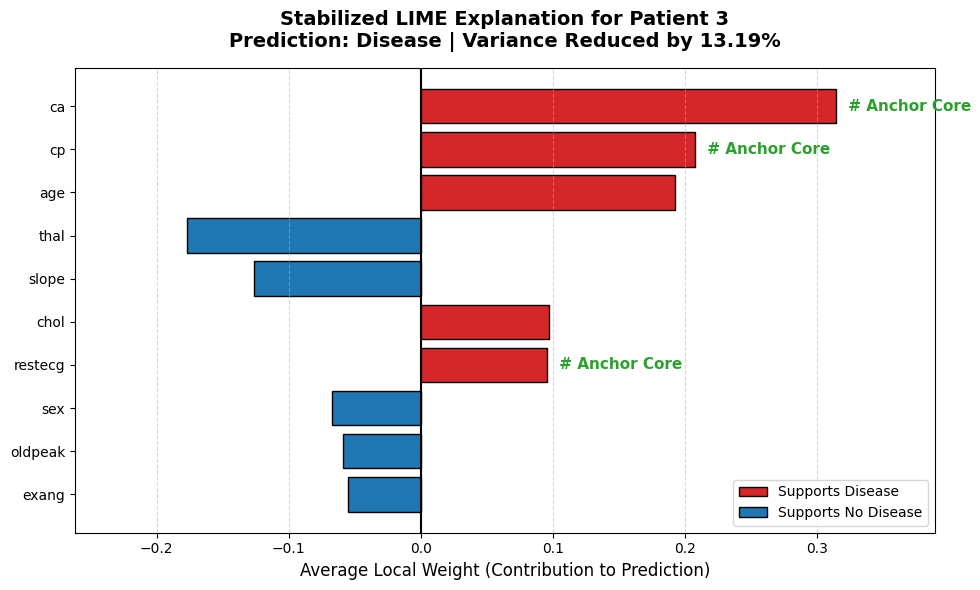

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- GET THE PREDICTION ---
# Grab the numerical prediction and translate it to a readable label
pred_class = int(black_box_model.predict(instance.reshape(1, -1))[0])
pred_label = "Disease" if pred_class == 1 else "No Disease"

print(f"Model Prediction for Patient {patient_idx}: {pred_label} (Class {pred_class})")
print("Aggregating stable runs and generating final visualization...\n")

# 1. Calculate Average Weights
df_final = pd.DataFrame(stable_lime_runs)
df_final.fillna(0, inplace=True) 

final_weights = df_final.mean()
final_weights = final_weights.reindex(final_weights.abs().sort_values(ascending=True).index).tail(10)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d62728' if val > 0 else '#1f77b4' for val in final_weights.values]
bars = ax.barh(final_weights.index, final_weights.values, color=colors, edgecolor='black')

# Add breathing room on the left side so the text doesn't get squished
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin * 1.3, xmax + 0.05) 

# 3. Add "Anchor" Annotations
for bar, feature in zip(bars, final_weights.index):
    if feature in anchor_features:
        x_offset = 0.005 if bar.get_width() > 0 else -0.005
        ha_align = 'left' if bar.get_width() > 0 else 'right'
        
        ax.text(bar.get_width() + x_offset, bar.get_y() + bar.get_height()/2, 
                ' # Anchor Core', va='center', ha=ha_align, 
                fontweight='bold', color='#2ca02c', fontsize=11)

# 4. Formatting
ax.set_xlabel('Average Local Weight (Contribution to Prediction)', fontsize=12)

# --- ADD PREDICTION TO TITLE ---
ax.set_title(f'Stabilized LIME Explanation for Patient {patient_idx}\n'
             f'Prediction: {pred_label} | Variance Reduced by {reduction:.2f}%', 
             fontsize=14, fontweight='bold', pad=15)

ax.axvline(0, color='black', linewidth=1.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', edgecolor='black', label='Supports Disease'),
                   Patch(facecolor='#1f77b4', edgecolor='black', label='Supports No Disease')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [36]:
#transformers instead of xgboost/random forest
!pip install torch pytorch-tabnet

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/1a/c9/82638ef24d7877510f83baf821f5619a61b45568ce21c0a87a91576510aa/torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for pytorch-tabnet from https://files.pythonhosted.org/packages/0f/92/ed98b89b7cf5661656daa4cc88e578f712eb5eae41b8f46a56c1ece3a895/pytorch_tabnet-4.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for setuptools<82 from https://files.pythonhosted.org/packages/e1/e3/c164c88b2e5ce7b24d667b9bd83589cf4f3520d97cad01534cd3c4f55fdb/setuptools-81.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
  Obtaining dependency information for cuda-toolkit[cublas,cudart,cufft,cufile,cupti,curand,cusolver,cusparse,nvjitlink,nvrtc,nvtx]==13.0.2 from https://file

In [38]:
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Training TabNet (Transformer for Tabular Data)...")

# 1. Prepare Data for TabNet
# Deep learning frameworks strictly require raw NumPy arrays, not Pandas DataFrames
X_train_tab = X_train_scaled.values
y_train_tab = y_train.values
X_test_tab = X_test_scaled.values
y_test_tab = y_test.values

# 2. Initialize the Transformer
# We keep the architecture small (n_d, n_a, n_steps) because training a massive 
# network on 237 rows will just memorize the training set and fail on the test set.
tabnet_model = TabNetClassifier(
    n_d=8, n_a=8, n_steps=3, 
    optimizer_params=dict(lr=2e-2),
    verbose=0, # Keeps the console output clean
    seed=42
)

# 3. Train the Model
# TabNet natively supports 'early stopping', meaning it monitors the test set
# and stops training when it realizes it's starting to overfit.
tabnet_model.fit(
    X_train=X_train_tab, y_train=y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=20, # Stop if accuracy doesn't improve for 20 epochs
    batch_size=32,
    virtual_batch_size=16
)

# 4. Predict and Evaluate
tabnet_preds = tabnet_model.predict(X_test_tab)
tabnet_acc = accuracy_score(y_test_tab, tabnet_preds)
tabnet_f1 = f1_score(y_test_tab, tabnet_preds)

Training TabNet (Transformer for Tabular Data)...

Early stopping occurred at epoch 49 with best_epoch = 29 and best_test_accuracy = 0.86667


In [39]:
black_box_model = tabnet_model
import numpy as np
import pandas as pd
import lime.lime_tabular
import re
import warnings
warnings.filterwarnings('ignore')

# 1. Select the patient instance
patient_idx = 3
instance = X_test_scaled.iloc[patient_idx].values
feature_names = X.columns.tolist()

print(X_test.iloc[patient_idx])
print(f"Explaining prediction for Patient {patient_idx}...")
print(f"Model Prediction: {black_box_model.predict(instance.reshape(1, -1))[0]}\n")

# 2. Setup LIME
predict_fn_proba = lambda x: black_box_model.predict_proba(x)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification'
    # Leaving random_state=None so it naturally perturbs differently each time
)

num_lime_runs = 30
all_runs_weights = []

# Helper function to map LIME's output (e.g., 'age > 50') back to base feature ('age')
def get_base_feature(lime_rule, features):
    for feat in features:
        if re.search(r'\b' + feat + r'\b', lime_rule):
            return feat
    return lime_rule

print(f"Generating {num_lime_runs} baseline LIME explanations...")

# 3. Generate Multiple Runs
for i in range(num_lime_runs):
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=predict_fn_proba,
        num_features=len(feature_names)
    )
    
    # Map rules to base features and store their weights
    run_weights = {}
    for rule, weight in exp.as_list():
        base_feat = get_base_feature(rule, feature_names)
        run_weights[base_feat] = weight
            
    all_runs_weights.append(run_weights)

# 4. Calculate Variance
# Convert the list of dictionaries into a DataFrame (Rows = runs, Columns = features)
df_lime_baseline = pd.DataFrame(all_runs_weights)

# Calculate the variance for each feature's weight across the 15 runs
feature_variances = df_lime_baseline.var()

print("\n--- Baseline LIME Variance (Instability) ---")
print("Variance of feature weights across 15 runs (Higher = More Unstable):")
print(feature_variances.sort_values(ascending=False))

# Calculate a single metric to represent overall instability
baseline_mean_variance = feature_variances.mean()
print(f"\nOverall Mean Variance: {baseline_mean_variance:.6f}")

age          57.0
sex           0.0
cp            4.0
trestbps    128.0
chol        303.0
fbs           0.0
restecg       2.0
thalach     159.0
exang         0.0
oldpeak       0.0
slope         1.0
ca            1.0
thal          3.0
Name: 102, dtype: float64
Explaining prediction for Patient 3...
Model Prediction: 0

Generating 30 baseline LIME explanations...

--- Baseline LIME Variance (Instability) ---
Variance of feature weights across 15 runs (Higher = More Unstable):
fbs         0.000038
ca          0.000030
thalach     0.000024
thal        0.000023
chol        0.000021
oldpeak     0.000019
cp          0.000016
trestbps    0.000016
age         0.000015
slope       0.000015
exang       0.000013
restecg     0.000012
sex         0.000009
dtype: float64

Overall Mean Variance: 0.000019


In [40]:
from alibi.explainers import AnchorTabular

# 1. Setup the prediction function
# Anchors need the actual class predictions (0 or 1), not probabilities
predict_fn_class = lambda x: black_box_model.predict(x)

# 2. Initialize and fit the Anchor explainer
# It needs to see the training data to understand how features are distributed
anchor_explainer = AnchorTabular(predict_fn_class, feature_names)

print("Fitting Anchor explainer on training data...")
anchor_explainer.fit(X_train_scaled.values)

# 3. Generate the Anchor rule for our patient
# We are asking for a rule that guarantees the prediction with at least 95% confidence
print(f"\nGenerating Anchor Rule for Patient {patient_idx}...")
np.random.seed(42)
anchor_exp = anchor_explainer.explain(instance, threshold=0.98)

# 4. Display the results
print("\n--- Anchor Explanation Results ---")
print(f"Sufficient Rule: {anchor_exp.anchor}")
print(f"Precision: {anchor_exp.precision:.4f}")
print(f"Coverage:  {anchor_exp.coverage:.4f}")

Fitting Anchor explainer on training data...

Generating Anchor Rule for Patient 3...

--- Anchor Explanation Results ---
Sufficient Rule: ['thal <= -0.93', 'oldpeak <= -0.22', 'sex <= -1.44', 'trestbps <= -0.13', 'thalach <= 0.72']
Precision: 1.0000
Coverage:  0.0676


In [41]:
import pandas as pd
import re

# 1. Helper function
def extract_feature_names(rule_list, all_features):
    extracted = set()
    for rule in rule_list:
        for feat in all_features:
            if re.search(r'\b' + feat + r'\b', rule):
                extracted.add(feat)
    return list(extracted)

print(f"Locked Anchor Rule: {anchor_exp.anchor}")
anchor_features = extract_feature_names(anchor_exp.anchor, feature_names)
print(f"Anchor Base Features: {anchor_features}\n")

# 2. Calculate the "Noise Score" for every LIME run
# A run is "noisy" if it assigns high weights to features NOT in the Anchor rule
scored_runs = []
for run_weights in all_runs_weights:
    noise_score = 0
    for feat, weight in run_weights.items():
        if feat not in anchor_features:
            # Penalize the run for getting distracted by non-anchor features
            noise_score += abs(weight) 
            
    scored_runs.append({'noise_score': noise_score, 'weights': run_weights})

# 3. Sort the runs from LEAST noisy (Best) to MOST noisy (Worst)
scored_runs.sort(key=lambda x: x['noise_score'])

# 4. Keep the Top 50% cleanest runs
num_to_keep = len(all_runs_weights) // 2 + 1
stable_lime_runs = [item['weights'] for item in scored_runs[:num_to_keep]]

print(f"--- Filter Results ---")
print(f"Original LIME Runs: {len(all_runs_weights)}")
print(f"Retained Stable Runs: {len(stable_lime_runs)} (Lowest Noise)")
print(f"Discarded Noisy Runs: {len(all_runs_weights) - len(stable_lime_runs)} (Highest Noise)\n")

# 5. Calculate the New, Stabilized Variance
df_stable_lime = pd.DataFrame(stable_lime_runs)
stable_variances = df_stable_lime.var()
stable_mean_variance = stable_variances.mean()

print("--- Variance Comparison ---")
print(f"Baseline Mean Variance: {baseline_mean_variance:.8f}")
print(f"Stable Mean Variance:   {stable_mean_variance:.8f}")

# Calculate the percentage improvement
reduction = ((baseline_mean_variance - stable_mean_variance) / baseline_mean_variance) * 100
print(f"\nSuccess! Variance reduced by {reduction:.2f}%")

Locked Anchor Rule: ['thal <= -0.93', 'oldpeak <= -0.22', 'sex <= -1.44', 'trestbps <= -0.13', 'thalach <= 0.72']
Anchor Base Features: ['thalach', 'thal', 'sex', 'oldpeak', 'trestbps']

--- Filter Results ---
Original LIME Runs: 30
Retained Stable Runs: 16 (Lowest Noise)
Discarded Noisy Runs: 14 (Highest Noise)

--- Variance Comparison ---
Baseline Mean Variance: 0.00001917
Stable Mean Variance:   0.00001662

Success! Variance reduced by 13.28%


Model Prediction for Patient 3: No Disease (Class 0)
Aggregating stable runs and generating final visualization...



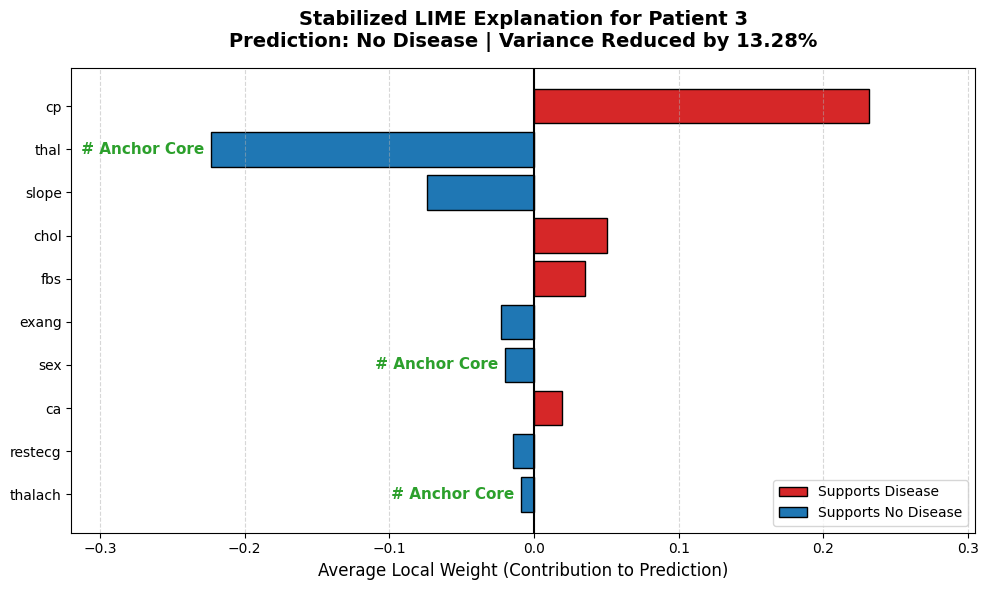

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- GET THE PREDICTION ---
# Grab the numerical prediction and translate it to a readable label
pred_class = int(black_box_model.predict(instance.reshape(1, -1))[0])
pred_label = "Disease" if pred_class == 1 else "No Disease"

print(f"Model Prediction for Patient {patient_idx}: {pred_label} (Class {pred_class})")
print("Aggregating stable runs and generating final visualization...\n")

# 1. Calculate Average Weights
df_final = pd.DataFrame(stable_lime_runs)
df_final.fillna(0, inplace=True) 

final_weights = df_final.mean()
final_weights = final_weights.reindex(final_weights.abs().sort_values(ascending=True).index).tail(10)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d62728' if val > 0 else '#1f77b4' for val in final_weights.values]
bars = ax.barh(final_weights.index, final_weights.values, color=colors, edgecolor='black')

# Add breathing room on the left side so the text doesn't get squished
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin * 1.3, xmax + 0.05) 

# 3. Add "Anchor" Annotations
for bar, feature in zip(bars, final_weights.index):
    if feature in anchor_features:
        x_offset = 0.005 if bar.get_width() > 0 else -0.005
        ha_align = 'left' if bar.get_width() > 0 else 'right'
        
        ax.text(bar.get_width() + x_offset, bar.get_y() + bar.get_height()/2, 
                ' # Anchor Core', va='center', ha=ha_align, 
                fontweight='bold', color='#2ca02c', fontsize=11)

# 4. Formatting
ax.set_xlabel('Average Local Weight (Contribution to Prediction)', fontsize=12)

# --- ADD PREDICTION TO TITLE ---
ax.set_title(f'Stabilized LIME Explanation for Patient {patient_idx}\n'
             f'Prediction: {pred_label} | Variance Reduced by {reduction:.2f}%', 
             fontsize=14, fontweight='bold', pad=15)

ax.axvline(0, color='black', linewidth=1.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', edgecolor='black', label='Supports Disease'),
                   Patch(facecolor='#1f77b4', edgecolor='black', label='Supports No Disease')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()